In [1]:
%matplotlib inline

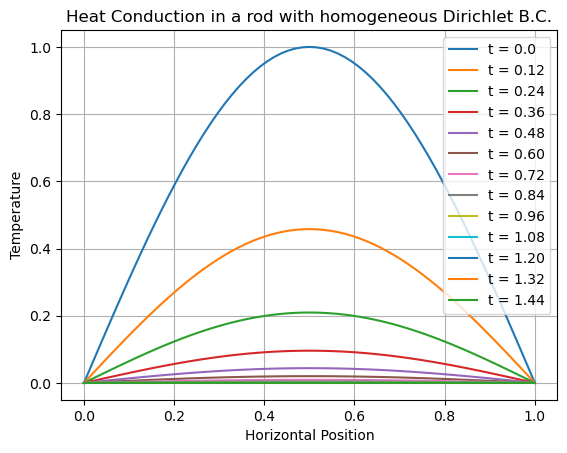

In [2]:
import matplotlib

import numpy as np          # Numerical arrays and math operations (used for sin, pi, isclose, argsort)
import matplotlib.pyplot as plt  # Plotting library for visualizing the solution at each time step

from mpi4py import MPI      # MPI parallelism interface — dolfinx requires this even for single-process runs
from petsc4py import PETSc  # PETSc linear algebra backend — used here for its ScalarType when defining constants

from dolfinx import mesh, fem           # mesh: create/manage the 1D domain; fem: function spaces, BCs, and FE functions
from dolfinx.fem.petsc import LinearProblem  # Assembles and solves the linear variational problem using PETSc
from ufl import TrialFunction, TestFunction, dx, dot, grad, inner
# TrialFunction: symbolic unknown u in the weak form
# TestFunction:  symbolic test function v in the weak form
# dx:            integration measure over the mesh domain
# dot:           inner product between vectors (used for grad(u)·grad(v))
# grad:          spatial gradient operator
# inner:         generalized inner product for scalars and tensors

if __name__ == "__main__":
    n_elements = 64

    # Create a 1D mesh over [0, 1] with n_elements uniform intervals
    domain = mesh.create_unit_interval(MPI.COMM_WORLD, n_elements)

    # Build a scalar Lagrange (P1) function space on the mesh —
    # each basis function is piecewise linear over each element
    lagrangePolynomialSpace1stOrder = fem.functionspace(
        domain,
        ("Lagrange", 1)
    )

    # Locate DOFs at the left boundary (x = 0) using a geometric test
    def boundary_left(x):
        return np.isclose(x[0], 0.0)

    # Locate DOFs at the right boundary (x = 1) using a geometric test
    def boundary_right(x):
        return np.isclose(x[0], 1.0)

    boundary_dofs_left = fem.locate_dofs_geometrical(
        lagrangePolynomialSpace1stOrder,
        boundary_left
    )
    boundary_dofs_right = fem.locate_dofs_geometrical(
        lagrangePolynomialSpace1stOrder,
        boundary_right
    )

    # Scalar zero constant used as the Dirichlet BC value on both ends
    uOnBoundary = fem.Constant(domain, PETSc.ScalarType(0.0))

    # Create homogeneous Dirichlet BCs: u = 0 at x=0 and x=1
    bc_left  = fem.dirichletbc(uOnBoundary, boundary_dofs_left,  lagrangePolynomialSpace1stOrder)
    bc_right = fem.dirichletbc(uOnBoundary, boundary_dofs_right, lagrangePolynomialSpace1stOrder)
    boundaryConds = [bc_left, bc_right]

    # Define u at t=0 as a FE function and project sin(πx) onto the function space
    uOld = fem.Function(lagrangePolynomialSpace1stOrder)
    uOld.interpolate(lambda x: np.sin(np.pi * x[0]))

    # Extract and sort DOF coordinates for ordered matplotlib plotting
    coords = lagrangePolynomialSpace1stOrder.tabulate_dof_coordinates()[:, 0]
    sort_idx = np.argsort(coords)

    # Plot the initial condition
    plt.figure()
    plt.plot(coords[sort_idx], uOld.x.array[sort_idx], label="t = 0.0")

    # Implicit Euler time step size dt
    timeStepLength = 0.12

    # Number of time steps to simulate
    nTimeSteps = 12

    # Zero heat source (F = 0), meaning no external heat is added to the rod
    heatSource = fem.Constant(domain, PETSc.ScalarType(0.0))

    # Symbolic trial function u (the unknown we solve for each time step)
    uTrial = TrialFunction(lagrangePolynomialSpace1stOrder)

    # Symbolic test function v (used to project the PDE into the weak form)
    vTest  = TestFunction(lagrangePolynomialSpace1stOrder)

    # Implicit Euler weak form, derived by multiplying the PDE by vTest and integrating by parts:
    #   LHS: ∫(u·v)dx + dt·∫(∇u·∇v)dx   ← comes from the time derivative + diffusion terms
    #   RHS: ∫(uOld·v)dx + dt·∫(F·v)dx  ← comes from the previous time step + heat source
    weakFormLHS = (
        inner(uTrial, vTest) * dx
        + timeStepLength * dot(grad(uTrial), grad(vTest)) * dx
    )
    weakFormRHS = (
        inner(uOld, vTest) * dx
        + timeStepLength * inner(heatSource, vTest) * dx
    )

    # FE function that will hold the solution u at each time step
    uSolution = fem.Function(lagrangePolynomialSpace1stOrder)

    # Assemble the linear problem once outside the loop — the LHS (stiffness matrix) is
    # constant across all time steps, so there is no need to rebuild it each iteration.
    # The RHS is re-evaluated automatically on each solve() call since uOld is updated in place
    problem = LinearProblem(
        weakFormLHS,
        weakFormRHS,
        bcs=boundaryConds,
        u=uSolution,
        petsc_options_prefix="heat_solver_"  # Unique solver prefix required by newer dolfinx versions
    )

    timeCurrent = 0.0
    for i in range(nTimeSteps):
        timeCurrent += timeStepLength

        # Re-evaluate the RHS with the updated uOld and solve the linear system
        problem.solve()

        # Overwrite uOld with the current solution to use as the previous step in the next iteration
        uOld.x.array[:] = uSolution.x.array

        # Plot the solution at this time step
        plt.plot(coords[sort_idx], uSolution.x.array[sort_idx], label=f"t = {timeCurrent:1.2f}")

    plt.legend()
    plt.title("Heat Conduction in a rod with homogeneous Dirichlet B.C.")
    plt.xlabel("Horizontal Position")
    plt.ylabel("Temperature")
    plt.grid()
    plt.show()